## ⚙️ **Libraries Import**

In [1]:
!pip install protobuf==3.20.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 6.1 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.0
    Uninstalling protobuf-6.33.0:
      Successfully uninstalled protobuf-6.33.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
onnx 1.18.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
a2a-sdk 0.3.10 requires protobuf>=5.29.5, but you have protobuf 3.20.3 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
tensorflow-me

In [2]:
!pip install timm transformers huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 115.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 88.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 100.0 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5

In [3]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils import class_weight

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
from torchvision.models import (
    efficientnet_v2_s, EfficientNet_V2_S_Weights,
    resnet50, ResNet50_Weights
)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# 1. Setup Device & Seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.benchmark = True
    print(f"🌱 Seed set to {seed}")

SEED = 42
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device: {device}")

🌱 Seed set to 42
🚀 Device: cuda


## ⚙️ **Global Config**

In [4]:
class Config:
    # Paths
    # KAGGLE_PATH = "/kaggle/input/an2dl-second-challenge/an2dl/"
    TRAIN_DIR = '/kaggle/input/cleaned-dataset/cleaned-dataset/train_data'
    TEST_DIR = '/kaggle/input/cleaned-dataset/cleaned-dataset/test_data'
    LABELS_FILE = '/kaggle/input/cleaned-dataset/cleaned-dataset/labels.csv'
    
    # Model Selection: 'phikon', 'uni', 'efficientnet', 'resnet50'
    MODEL_NAME = "plip" 
    
    # Image Settings (Phikon/UNI prefer 224 or 256)
    IMG_SIZE = (224, 224) 

    USE_MASK = False        # Set to False to keep background (don't black it out)
    CROP_TO_ROI = False      # Set to False to use the whole image
    PAD_TO_SQUARE = True    # Set to True to avoid stretching/distorting the image
    
    # Training Hyperparameters
    BATCH_SIZE = 32
    EPOCHS_HEAD = 10       # Head needs less time for Foundation models
    EPOCHS_FINE = 200      # Fine-tuning
    LR_HEAD = 3e-4        # Lower LR for ViTs
    LR_FINE = 1e-5
    PATIENCE = 20
    DROPOUT = 0.4
    
    # HuggingFace Token (Required for UNI, Optional for others)
    # Get yours at https://huggingface.co/settings/tokens
    HF_TOKEN = "YOUR_HUGGINGFACE_TOKEN_HERE" 
    
CONFIG = Config()

## 🧼 **Data cleaning**

In [5]:
import math

def visualize_rejected_images(rejected_log, max_images=50):
    """
    Plots a grid of rejected images with their reasons.
    Limits display to max_images to prevent crashing the notebook.
    """
    if not rejected_log:
        print("🎉 No images were rejected!")
        return

    n = len(rejected_log)
    display_n = min(n, max_images)
    print(f"👁️ Visualizing {display_n} out of {n} rejected images...")
    
    cols = 5
    rows = math.ceil(display_n / cols)
    
    plt.figure(figsize=(20, 4 * rows))
    
    # Sort by reason so conflicts appear together
    sorted_log = sorted(rejected_log, key=lambda x: x['reason'])[:display_n]
    
    for i, item in enumerate(sorted_log):
        plt.subplot(rows, cols, i + 1)
        
        # Load image
        img = cv2.imread(item['path'])
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.imshow(img)
        else:
            plt.text(0.5, 0.5, "Img Load Error", ha='center')
            
        # Color code the title
        title_color = 'black'
        if "Conflict" in item['reason']:
            title_color = 'red'
        elif "Low Info" in item['reason']:
            title_color = 'gray'
        elif "Redundant" in item['reason']:
            title_color = 'blue'
            
        plt.title(f"{item['filename']}\nLabel: {item['label']}\n{item['reason']}", 
                  fontsize=9, color=title_color, fontweight='bold')
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

In [6]:
# --- DATA CLEANING UTILITIES ---

def get_image_fingerprint(img):
    """
    Resizes image to 8x8 grayscale and flattens it.
    Returns a hashable tuple representing the visual content.
    """
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Resize to tiny grid (fast, ignores minor noise, captures structure)
    img_small = cv2.resize(img_gray, (8, 8), interpolation=cv2.INTER_AREA)
    return img_small

def get_canonical_id(img):
    """
    Generates fingerprints for all 8 geometric transformations of the image.
    Returns the lexicographically smallest fingerprint (Canonical ID).
    This ensures an image and its rotated version get the SAME ID.
    """
    fingerprints = []
    
    # Base image
    base = get_image_fingerprint(img)
    
    # Generate all 8 orientations
    # 0, 90, 180, 270 rotations
    curr = base
    for _ in range(4):
        fingerprints.append(tuple(curr.flatten()))
        # Flip current
        flipped = cv2.flip(curr, 1)
        fingerprints.append(tuple(flipped.flatten()))
        # Rotate 90 deg for next iter
        curr = cv2.rotate(curr, cv2.ROTATE_90_CLOCKWISE)
        
    # The canonical ID is the minimum hash value found among all orientations
    return min(fingerprints)

def clean_dataset_with_logging(folder_path, labels_df, threshold_std=5):
    """
    Scans folder for outliers and duplicates.
    Returns:
      1. valid_filenames: List of files to keep.
      2. rejected_log: List of dicts {'filename', 'reason', 'path'} for visualization.
    """
    print("🧹 Starting Data Cleaning with Visualization Logging...")
    
    img_files = sorted([f for f in os.listdir(folder_path) if f.startswith('img_') and f.endswith('.png')])
    label_map = dict(zip(labels_df['sample_index'], labels_df['label']))
    
    visual_groups = {} 
    rejected_log = [] # Store rejected images here
    valid_filenames = []
    
    # --- PHASE 1: SCAN & DETECT OUTLIERS ---
    print(f"   Scanning {len(img_files)} images...")
    for filename in img_files:
        path = os.path.join(folder_path, filename)
        img = cv2.imread(path)
        if img is None: continue
        
        # 1. Outlier Check
        std_dev = np.std(img)
        if std_dev < threshold_std:
            rejected_log.append({
                'filename': filename,
                'path': path,
                'reason': f"Low Info (Std: {std_dev:.1f})",
                'label': label_map.get(filename, 'N/A')
            })
            continue 
            
        # 2. Fingerprinting for Duplicates
        can_id = get_canonical_id(img)
        if can_id not in visual_groups:
            visual_groups[can_id] = []
        visual_groups[can_id].append(filename)

    # --- PHASE 2: RESOLVE DUPLICATES & CONFLICTS ---
    for can_id, filenames in visual_groups.items():
        # Case A: Unique Image (Keep it)
        if len(filenames) == 1:
            valid_filenames.append(filenames[0])
            continue
            
        # Case B: Duplicates Found
        current_labels = [label_map.get(f, 'Unknown') for f in filenames]
        unique_labels = set(current_labels)
        
        if len(unique_labels) == 1:
            # SAME LABELS: Keep first, reject others as "Redundant"
            keep = filenames[0]
            valid_filenames.append(keep)
            
            for drop_file in filenames[1:]:
                rejected_log.append({
                    'filename': drop_file,
                    'path': os.path.join(folder_path, drop_file),
                    'reason': f"Redundant Copy (Kept {keep})",
                    'label': current_labels[0]
                })
        else:
            # DIFFERENT LABELS: Conflict! Reject ALL.
            conflict_str = " vs ".join([str(l) for l in unique_labels])
            for f, l in zip(filenames, current_labels):
                rejected_log.append({
                    'filename': f,
                    'path': os.path.join(folder_path, f),
                    'reason': f"Conflict: {conflict_str}",
                    'label': l
                })

    print(f"✅ retained {len(valid_filenames)} images.")
    print(f"❌ Rejected {len(rejected_log)} images.")
    
    return valid_filenames, rejected_log

## ⏳ **Data Loading**

In [7]:
def pad_to_square(img, mask=None):
    """
    Pads an image to make it square without stretching the content.
    Crucial for pathology to preserve cell shape.
    """
    h, w = img.shape[:2]
    if h == w:
        return img, mask
    
    diff = abs(h - w)
    pad1 = diff // 2
    pad2 = diff - pad1
    
    if h > w: # Pad width
        padding = ((0, 0), (pad1, pad2), (0, 0)) # (top, bot), (left, right), (chan)
        if mask is not None:
            mask_padding = ((0, 0), (pad1, pad2))
    else: # Pad height
        padding = ((pad1, pad2), (0, 0), (0, 0))
        if mask is not None:
            mask_padding = ((pad1, pad2), (0, 0))
            
    img = np.pad(img, padding, mode='constant', constant_values=255) # Pad with White (255) for medical
    if mask is not None:
        mask = np.pad(mask, mask_padding, mode='constant', constant_values=0)
        
    return img, mask

In [8]:
# --- UNIFIED LOADING FUNCTION ---

def load_images_with_smart_crop(folder_path, file_list=None, target_size=(224, 224)):
    images_processed = []
    filenames_out = []
    
    if file_list is None:
        if not os.path.exists(folder_path): return np.array([]), []
        file_list = sorted([f for f in os.listdir(folder_path) if f.startswith('img_') and f.endswith('.png')])
    
    print(f"📂 Processing {len(file_list)} images (Mask={CONFIG.USE_MASK}, Crop={CONFIG.CROP_TO_ROI})...")

    for filename in file_list:
        img_path = os.path.join(folder_path, filename)
        mask_path = os.path.join(folder_path, filename.replace('img_', 'mask_'))
        
        img = cv2.imread(img_path)
        if img is None: continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Load mask if needed for cropping or masking
        mask = None
        if os.path.exists(mask_path):
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        else:
            mask = np.ones(img.shape[:2], dtype=np.uint8) * 255

        # 1. OPTIONAL CROP TO ROI (Bounding Box)
        if CONFIG.CROP_TO_ROI:
            rows, cols = np.any(mask > 0, axis=1), np.any(mask > 0, axis=0)
            if np.any(rows) and np.any(cols):
                y_min, y_max = np.where(rows)[0][[0, -1]]
                x_min, x_max = np.where(cols)[0][[0, -1]]
                pad = 20
                h, w = img.shape[:2]
                y_min, y_max = max(0, y_min - pad), min(h, y_max + pad)
                x_min, x_max = max(0, x_min - pad), min(w, x_max + pad)
                img = img[y_min:y_max, x_min:x_max]
                mask = mask[y_min:y_max, x_min:x_max]

        # 2. OPTIONAL MASKING (Black out background)
        if CONFIG.USE_MASK:
            # Only keep parts where mask > 0
            img = cv2.bitwise_and(img, img, mask=mask)
            # Optional: Make the background white instead of black?
            # Medical models usually prefer white background.
            # img[mask == 0] = 255 

        # 3. SQUARE PADDING (Fix Aspect Ratio)
        if CONFIG.PAD_TO_SQUARE:
            img, mask = pad_to_square(img, mask)

        # 4. Final Resize & Normalize
        img = cv2.resize(img, target_size, interpolation=cv2.INTER_LINEAR)
        
        img = (img / 255.0).astype(np.float32)
        images_processed.append(img)
        filenames_out.append(filename)
        
    return np.array(images_processed), filenames_out

# --- EXECUTION ---

# 1. Load Labels DF First
labels_df = pd.read_csv(CONFIG.LABELS_FILE)

# 2. Run Cleaning (returns a LIST of valid filenames)
clean_files_list, rejected_log = clean_dataset_with_logging(CONFIG.TRAIN_DIR, labels_df)
# Optional: visualize_rejected_images(rejected_log)

# 3. Load TRAIN Data (Passing the specific list)
X_raw, train_fnames = load_images_with_smart_crop(
    CONFIG.TRAIN_DIR, 
    file_list=clean_files_list, 
    target_size=CONFIG.IMG_SIZE
)

# 4. Sync Labels
labels_df = labels_df[labels_df['sample_index'].isin(train_fnames)]
labels_df = labels_df.set_index('sample_index').loc[train_fnames].reset_index()

# 5. Encode
le = LabelEncoder()
y_encoded = le.fit_transform(labels_df['label'])

print(f"✅ Final X Shape: {X_raw.shape}")
print(f"✅ Final y Shape: {y_encoded.shape}")

🧹 Starting Data Cleaning with Visualization Logging...
   Scanning 1262 images...
✅ retained 1250 images.
❌ Rejected 12 images.
📂 Processing 1250 images (Mask=False, Crop=False)...
✅ Final X Shape: (1250, 224, 224, 3)
✅ Final y Shape: (1250,)


## 🔎 **Data Exploration**

##  📄 **Data Preprocessing**

In [9]:
class MedicalDataset(Dataset):
    def __init__(self, images, labels=None, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = self.images[idx]
        
        if self.transform:
            image = self.transform(image)
            
        if self.labels is not None:
            label = torch.tensor(self.labels[idx], dtype=torch.long)
            return image, label
        return image

# --- AUGMENTATION WITH AUTO-AUGMENT ---
def get_transforms():
    train_tf = v2.Compose([
        v2.ToImage(),
        # ⚡ Auto Augmentation: Automatically learns best transforms
        v2.RandAugment(num_ops=2, magnitude=3), 
        
        v2.ToDtype(torch.float32, scale=True), 
        v2.RandomResizedCrop(size=CONFIG.IMG_SIZE, scale=(0.85, 1.0), antialias=True),
        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomVerticalFlip(p=0.5),
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    val_tf = v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    return train_tf, val_tf

# Split Data
X_train, X_val, y_train, y_val = train_test_split(
    X_raw, y_encoded, test_size=0.15, stratify=y_encoded, random_state=SEED
)

# Create Datasets
train_tf, val_tf = get_transforms()
train_ds = MedicalDataset(X_train, y_train, transform=train_tf)
val_ds = MedicalDataset(X_val, y_val, transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=CONFIG.BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=CONFIG.BATCH_SIZE, shuffle=False, num_workers=2)

##  🛠️ **Model building**

In [10]:
# %% [code]
import timm
from transformers import AutoImageProcessor, ViTModel, CLIPVisionModel

def build_model(model_name, num_classes, dropout_rate=0.3):
    print(f"🏗️ Building model: {model_name.upper()}")
    
    # --- OPTION NEW: PLIP (Pathology CLIP) ---
    if model_name == "plip":
        print("   Loading vinid/plip (ViT-B/32)...")
        # We only load the Vision Tower of CLIP
        base_model = CLIPVisionModel.from_pretrained("vinid/plip")
        
        class PLIPClassifier(nn.Module):
            def __init__(self, base, n_classes, drop):
                super().__init__()
                self.backbone = base
                # PLIP (ViT-B/32) hidden size is 768
                self.head = nn.Sequential(
                    nn.Dropout(drop),
                    nn.Linear(768, 512),
                    nn.GELU(),
                    nn.Dropout(drop),
                    nn.Linear(512, n_classes)
                )

            def forward(self, x):
                # CLIPVisionModel outputs specific object
                # We take last_hidden_state[:, 0, :] which is the [CLS] token representation
                out = self.backbone(x).last_hidden_state[:, 0, :]
                return self.head(out)
        
        model = PLIPClassifier(base_model, num_classes, dropout_rate)

    # --- OPTION A: OWKIN PHIKON ---
    elif model_name == "phikon":
        print("   Loading Owkin/Phikon (ViT-Base)...")
        base_model = ViTModel.from_pretrained("owkin/phikon", add_pooling_layer=False)
        
        class PhikonClassifier(nn.Module):
            def __init__(self, base, n_classes, drop):
                super().__init__()
                self.base = base
                self.norm = nn.LayerNorm(768) 
                self.head = nn.Sequential(
                    nn.Dropout(drop),
                    nn.Linear(768, 512),
                    nn.GELU(),
                    nn.Dropout(drop),
                    nn.Linear(512, n_classes)
                )
            def forward(self, x):
                out = self.base(x).last_hidden_state[:, 0]
                out = self.norm(out)
                return self.head(out)
                
        model = PhikonClassifier(base_model, num_classes, dropout_rate)

    # --- OPTION B: MAHMOOD LAB UNI ---
    elif model_name == "uni":
        print("   Loading MahmoodLab/UNI (ViT-Large)...")
        try:
            model = timm.create_model(
                "hf_hub:MahmoodLab/UNI", 
                pretrained=True, 
                num_classes=num_classes,
                drop_rate=dropout_rate
            )
        except Exception as e:
            print(f"   ❌ Could not load UNI directly: {e}")
            model = timm.create_model("vit_large_patch16_224", pretrained=True, num_classes=num_classes)

    # --- OPTION C: EFFICIENTNET V2 ---
    elif model_name == "efficientnet":
        weights = EfficientNet_V2_S_Weights.DEFAULT
        model = efficientnet_v2_s(weights=weights)
        input_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(input_features, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(), 
            nn.Dropout(p=dropout_rate),
            nn.Linear(256, num_classes)
        )

    # --- OPTION D: RESNET50 ---
    elif model_name == "resnet50":
        weights = ResNet50_Weights.DEFAULT
        model = resnet50(weights=weights)
        input_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(input_features, num_classes)
        )
        
    else:
        raise ValueError(f"Model {model_name} not found.")
        
    return model.to(device)

def set_parameter_requires_grad(model, feature_extracting):
    # Helper to freeze/unfreeze
    if feature_extracting:
        # 1. Freeze EVERYTHING first
        for param in model.parameters():
            param.requires_grad = False
            
        # 2. Unfreeze specific Classification Heads
        if hasattr(model, 'classifier'): # EfficientNet
            for param in model.classifier.parameters(): 
                param.requires_grad = True
                
        elif hasattr(model, 'fc'): # ResNet
            for param in model.fc.parameters(): 
                param.requires_grad = True
                
        elif hasattr(model, 'head'): # Phikon, UNI, PLIP
            for param in model.head.parameters(): 
                param.requires_grad = True
                
        # 3. Unfreeze Norms if present (Phikon)
        if hasattr(model, 'norm'):
            for param in model.norm.parameters():
                param.requires_grad = True

        # 4. PLIP specific: It acts as a wrapper, ensure backbone is frozen
        if hasattr(model, 'backbone'):
             for param in model.backbone.parameters():
                param.requires_grad = False
                
        print("✅ Model frozen. Only head (and norm) are trainable.")
        
    else:
        for param in model.parameters():
            param.requires_grad = True
        print("✅ Model unfrozen. All layers are trainable.")

2025-12-06 14:48:49.258308: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765032529.436930      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765032529.484964      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## 🧠 **Model Training**

In [11]:
class Trainer:
    def __init__(self, model, criterion, optimizer, scaler, device):
        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.scaler = scaler
        self.device = device
        self.history = {'train_loss': [], 'train_f1': [], 'val_loss': [], 'val_f1': []}
        
    def train_epoch(self, loader):
        self.model.train()
        total_loss, all_preds, all_labels = 0, [], []
        
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(self.device), lbls.to(self.device)
            self.optimizer.zero_grad()
            
            with torch.amp.autocast(device_type=self.device.type, enabled=(self.device.type == 'cuda')):
                logits = self.model(imgs)
                loss = self.criterion(logits, lbls)
                
            self.scaler.scale(loss).backward()
            self.scaler.step(self.optimizer)
            self.scaler.update()
            
            total_loss += loss.item() * imgs.size(0)
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())
            
        return total_loss / len(loader.dataset), f1_score(all_labels, all_preds, average='weighted')

    def validate_epoch(self, loader):
        self.model.eval()
        total_loss, all_preds, all_labels = 0, [], []
        
        with torch.no_grad():
            for imgs, lbls in loader:
                imgs, lbls = imgs.to(self.device), lbls.to(self.device)
                with torch.amp.autocast(device_type=self.device.type, enabled=(self.device.type == 'cuda')):
                    logits = self.model(imgs)
                    loss = self.criterion(logits, lbls)
                
                total_loss += loss.item() * imgs.size(0)
                all_preds.extend(logits.argmax(dim=1).cpu().numpy())
                all_labels.extend(lbls.cpu().numpy())
                
        return total_loss / len(loader.dataset), f1_score(all_labels, all_preds, average='weighted')

    def fit(self, train_loader, val_loader, epochs, patience, save_name):
        best_f1 = 0.0
        patience_counter = 0
        
        for epoch in range(epochs):
            t_loss, t_f1 = self.train_epoch(train_loader)
            v_loss, v_f1 = self.validate_epoch(val_loader)
            
            self.history['train_loss'].append(t_loss)
            self.history['val_f1'].append(v_f1)
            # Add others as needed
            
            print(f"Epoch {epoch+1}/{epochs} | T_Loss: {t_loss:.4f} T_F1: {t_f1:.4f} | V_Loss: {v_loss:.4f} V_F1: {v_f1:.4f}")
            
            if v_f1 > best_f1:
                best_f1 = v_f1
                patience_counter = 0
                torch.save(self.model.state_dict(), f"{save_name}.pt")
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"🛑 Early stopping at epoch {epoch+1}")
                    break
        
        print(f"Restoring best model with F1: {best_f1:.4f}")
        self.model.load_state_dict(torch.load(f"{save_name}.pt"))

🏗️ Building model: PLIP
   Loading vinid/plip (ViT-B/32)...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]


🔥 STAGE 1: Training Head...
✅ Model frozen. Only head (and norm) are trainable.


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Epoch 1/10 | T_Loss: 1.4060 T_F1: 0.2367 | V_Loss: 1.4003 V_F1: 0.0267
Epoch 2/10 | T_Loss: 1.3951 T_F1: 0.2199 | V_Loss: 1.3872 V_F1: 0.1499
Epoch 3/10 | T_Loss: 1.3881 T_F1: 0.2957 | V_Loss: 1.3927 V_F1: 0.0551
Epoch 4/10 | T_Loss: 1.3859 T_F1: 0.2371 | V_Loss: 1.3939 V_F1: 0.2172
Epoch 5/10 | T_Loss: 1.3927 T_F1: 0.2734 | V_Loss: 1.3902 V_F1: 0.3254
Epoch 6/10 | T_Loss: 1.3927 T_F1: 0.2877 | V_Loss: 1.3915 V_F1: 0.1725
Epoch 7/10 | T_Loss: 1.3805 T_F1: 0.3192 | V_Loss: 1.3912 V_F1: 0.1808
Epoch 8/10 | T_Loss: 1.3878 T_F1: 0.2344 | V_Loss: 1.3915 V_F1: 0.2271
🛑 Early stopping at epoch 8
Restoring best model with F1: 0.3254

🔥 STAGE 2: Fine Tuning Backbone...
✅ Model unfrozen. All layers are trainable.
Epoch 1/200 | T_Loss: 1.3940 T_F1: 0.2769 | V_Loss: 1.3897 V_F1: 0.1158
Epoch 2/200 | T_Loss: 1.3970 T_F1: 0.2954 | V_Loss: 1.3866 V_F1: 0.1896
Epoch 3/200 | T_Loss: 1.4006 T_F1: 0.2780 | V_Loss: 1.3863 V_F1: 0.1039
Epoch 4/200 | T_Loss: 1.3958 T_F1: 0.2522 | V_Loss: 1.3879 V_F1: 0.1043

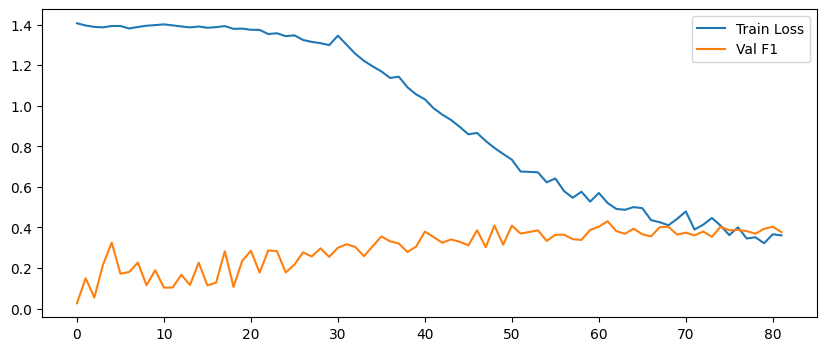

In [12]:
# 1. Initialize Model
num_classes = len(le.classes_)
model = build_model(CONFIG.MODEL_NAME, num_classes, CONFIG.DROPOUT)

# 2. Setup Tools
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float).to(device))
scaler = torch.amp.GradScaler('cuda')

# 3. STAGE 1: Train Head Only
print("\n🔥 STAGE 1: Training Head...")
set_parameter_requires_grad(model, feature_extracting=True)
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG.LR_HEAD)

trainer = Trainer(model, criterion, optimizer, scaler, device)
trainer.fit(train_loader, val_loader, epochs=CONFIG.EPOCHS_HEAD, patience=3, save_name="stage1_model")

# 4. STAGE 2: Fine Tuning
print("\n🔥 STAGE 2: Fine Tuning Backbone...")
set_parameter_requires_grad(model, feature_extracting=False) # Unfreeze all
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG.LR_FINE, weight_decay=1e-4)

# Update trainer with new optimizer
trainer.optimizer = optimizer
trainer.fit(train_loader, val_loader, epochs=CONFIG.EPOCHS_FINE, patience=CONFIG.PATIENCE, save_name="best_model")

# 5. Plot Results
plt.figure(figsize=(10,4))
plt.plot(trainer.history['train_loss'], label='Train Loss')
plt.plot(trainer.history['val_f1'], label='Val F1')
plt.legend()
plt.show()

## 💫 **Confusion Matrix**

In [13]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

def generate_confusion_matrix(model, loader, device, class_names):
    """
    Runs the model on the loader, generates predictions, and plots the matrix.
    """
    model.eval()
    all_preds = []
    all_labels = []
    
    print("📊 Generating Confusion Matrix...")
    
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            lbls = lbls.to(device)
            
            # Use AutoCast for consistent performance
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(imgs)
            
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())
            
    # Calculate Matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    # Calculate Normalized Matrix (Recall per class)
    # epsilon added to prevent division by zero
    cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)
    
    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # Raw Counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, 
                ax=axes[0], square=True)
    axes[0].set_title('Confusion Matrix (Raw Counts)', fontweight='bold')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')
    
    # Normalized
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', 
                xticklabels=class_names, yticklabels=class_names, 
                ax=axes[1], square=True)
    axes[1].set_title('Confusion Matrix (Normalized %)', fontweight='bold')
    axes[1].set_ylabel('True Label')
    axes[1].set_xlabel('Predicted Label')
    
    plt.tight_layout()
    plt.show()
    
    return all_labels, all_preds


🧐 Evaluating Best Model on Validation Set...
📊 Generating Confusion Matrix...


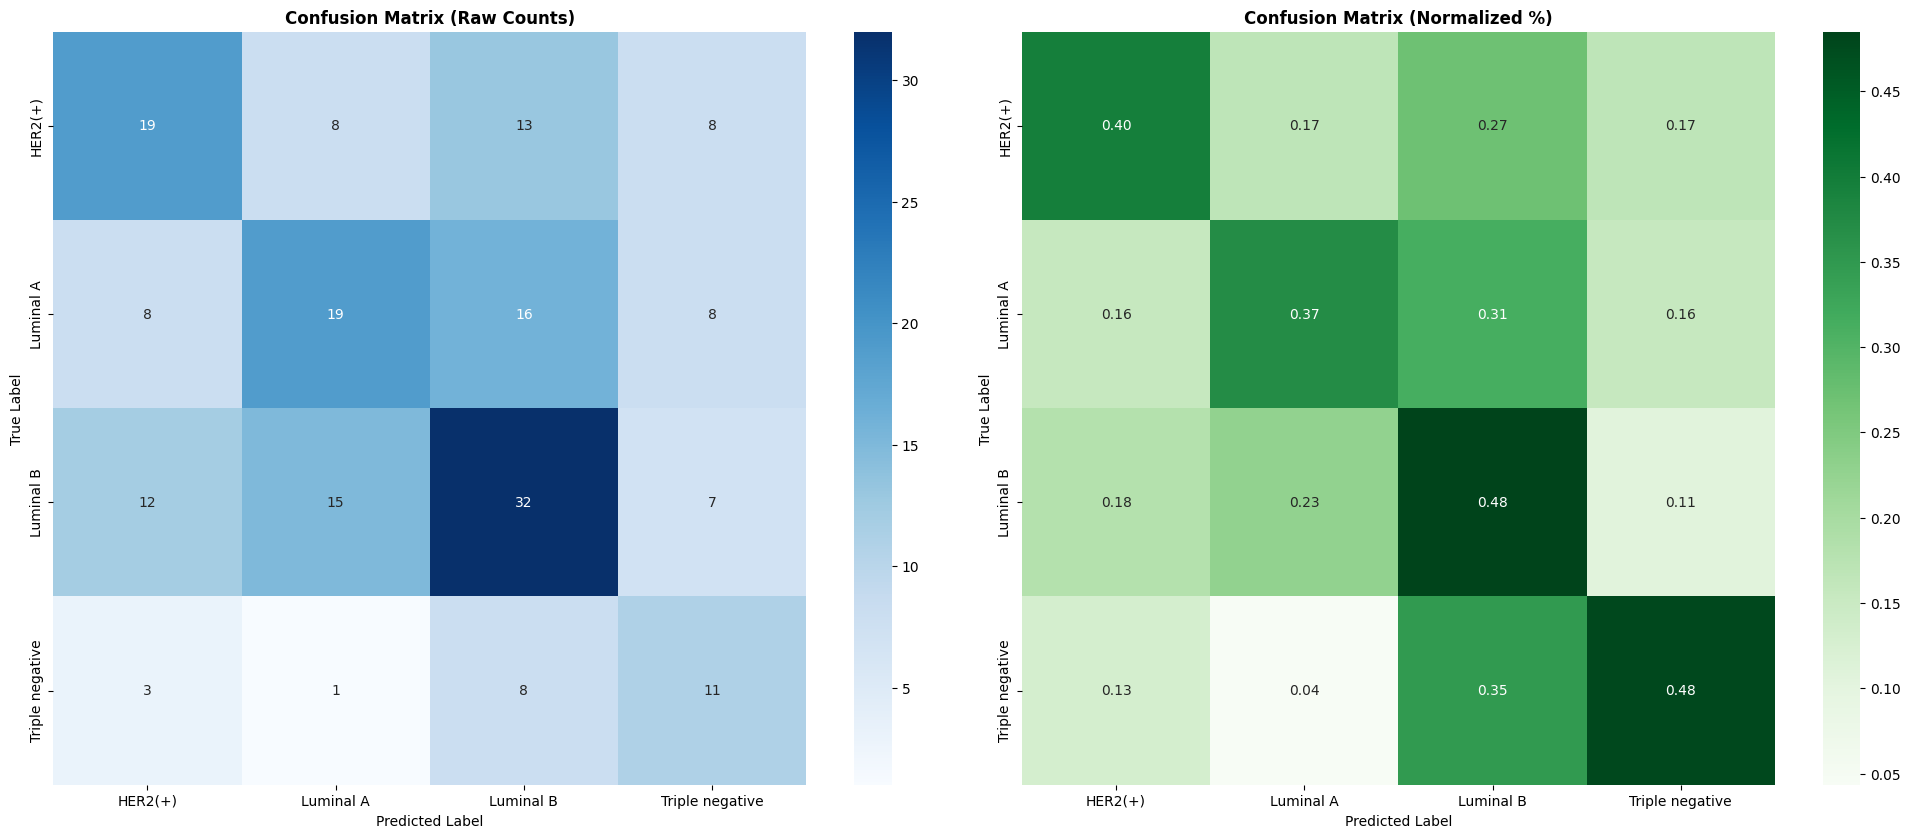


📑 Classification Report:
                 precision    recall  f1-score   support

        HER2(+)       0.45      0.40      0.42        48
      Luminal A       0.44      0.37      0.40        51
      Luminal B       0.46      0.48      0.47        66
Triple negative       0.32      0.48      0.39        23

       accuracy                           0.43       188
      macro avg       0.42      0.43      0.42       188
   weighted avg       0.44      0.43      0.43       188



In [14]:
print("\n🧐 Evaluating Best Model on Validation Set...")

# 1. Ensure we have the best model loaded (Trainer does this automatically, but just to be safe)
model.load_state_dict(torch.load("best_model.pt"))

# 2. Run the Visualization
# le.classes_ contains the names ['Dysplasia', 'Normal', 'Cancer'] etc.
true_labels, pred_labels = generate_confusion_matrix(model, val_loader, device, le.classes_)

# 3. Print a detailed Text Report as well
print("\n📑 Classification Report:")
print(classification_report(true_labels, pred_labels, target_names=le.classes_))

## 🕹️ **Use the Model - Make Inference**

In [15]:
print("\n🔎 Processing Test Data...")

# 1. Reuse the unified loader with file_list=None to scan the whole folder
X_test, test_filenames = load_images_with_smart_crop(
    CONFIG.TEST_DIR, 
    file_list=None,  # None triggers "Load All" mode
    target_size=CONFIG.IMG_SIZE
)

if len(X_test) > 0:
    # 2. Create Loader (Use Val transforms for normalization)
    test_ds = MedicalDataset(X_test, labels=None, transform=val_tf)
    test_loader = DataLoader(test_ds, batch_size=CONFIG.BATCH_SIZE, shuffle=False)

    # 3. Predict
    print("🔮 Running Inference...")
    model.eval()
    all_preds = []

    with torch.no_grad():
        for imgs in test_loader:
            imgs = imgs.to(device)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(imgs)
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())

    # 4. Decode & Save
    predicted_labels = le.inverse_transform(all_preds)

    submission = pd.DataFrame({
        'sample_index': test_filenames,
        'label': predicted_labels
    })

    submission.to_csv("submission.csv", index=False)
    print("🏆 Submission saved successfully!")
    print(submission.head())
else:
    print("⚠️ No images found in Test Directory.")


🔎 Processing Test Data...
📂 Processing 954 images (Mask=False, Crop=False)...
🔮 Running Inference...
🏆 Submission saved successfully!
   sample_index      label
0  img_0000.png  Luminal A
1  img_0001.png  Luminal A
2  img_0002.png  Luminal A
3  img_0003.png  Luminal A
4  img_0004.png  Luminal A
